In [40]:
import pandas as pd

In [41]:
df = pd.read_csv('accident.csv')

In [42]:
df.head()

,Age,Gender,Speed_of_Impact,Helmet_Used,Seatbelt_Used,Survived
0,56,Female,27.0,No,No,1
1,69,Female,46.0,No,Yes,1
2,46,Male,46.0,Yes,Yes,0
3,32,Male,117.0,No,Yes,0
4,60,Female,40.0,Yes,Yes,0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              200 non-null    int64  
 1   Gender           199 non-null    object 
 2   Speed_of_Impact  197 non-null    float64
 3   Helmet_Used      200 non-null    object 
 4   Seatbelt_Used    200 non-null    object 
 5   Survived         200 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 9.5+ KB


In [44]:
df.isnull().sum()

Age                0
Gender             1
Speed_of_Impact    3
Helmet_Used        0
Seatbelt_Used      0
Survived           0
dtype: int64

In [45]:
df['Gender'].fillna(df['Gender'].mode(),inplace=True)

In [46]:
df['Speed_of_Impact'].fillna(df['Speed_of_Impact'].median(),inplace=True)

In [47]:
df.isnull().sum()

Age                0
Gender             1
Speed_of_Impact    0
Helmet_Used        0
Seatbelt_Used      0
Survived           0
dtype: int64

In [48]:
df = df.dropna()

In [49]:
df.isna()

,Age,Gender,Speed_of_Impact,Helmet_Used,Seatbelt_Used,Survived
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
195,False,False,False,False,False,False
196,False,False,False,False,False,False
197,False,False,False,False,False,False
198,False,False,False,False,False,False


In [50]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [51]:
oe = OrdinalEncoder()
oe.fit(df[['Gender','Helmet_Used','Seatbelt_Used']])

OrdinalEncoder()

In [52]:
df[['Gender','Helmet_Used','Seatbelt_Used']] = oe.transform(df[['Gender','Helmet_Used','Seatbelt_Used']])

In [53]:
df

,Age,Gender,Speed_of_Impact,Helmet_Used,Seatbelt_Used,Survived
0,56,0.0,27.0,0.0,0.0,1
1,69,0.0,46.0,0.0,1.0,1
2,46,1.0,46.0,1.0,1.0,0
3,32,1.0,117.0,0.0,1.0,0
4,60,0.0,40.0,1.0,1.0,0
...,...,...,...,...,...,...
195,69,0.0,111.0,0.0,1.0,1
196,30,0.0,51.0,0.0,1.0,1
197,58,1.0,110.0,0.0,1.0,1
198,20,1.0,103.0,0.0,1.0,1


In [54]:
X = df.drop('Survived',axis=1)
y = df['Survived']

In [55]:
df.isnull().sum()

Age                0
Gender             0
Speed_of_Impact    0
Helmet_Used        0
Seatbelt_Used      0
Survived           0
dtype: int64

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

In [57]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [61]:
#Sequential model
model = Sequential([
      Dense(16, activation='relu', input_shape=(X.shape[1],)),
      Dense(1, activation='sigmoid')
])

model.compile(optimizer=keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy', 'precision'])

/opt/miniconda3/envs/P1/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113 (452.00 B)

 Trainable params: 113 (452.00 B)

 Non-trainable params: 0 (0.00 B)

In [63]:
history = model.fit(X_train.values, y_train.values.reshape(-1, 1), epochs=30, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4943 - loss: 24.3726 - precision: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 27.8273 - val_precision: 0.0000e+00
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4987 - loss: 21.5995 - precision: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 25.9904 - val_precision: 0.0000e+00
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5442 - loss: 18.4848 - precision: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 24.1651 - val_precision: 0.0000e+00
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5034 - loss: 19.2422 - precision: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 22.3201 - val_precision: 0.0000e+00
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5008 - loss: 17.3762 - precision: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 20.5044 - val_precision: 0.0000e+00
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5147 - loss: 15.0709 - precision: 0.0000e+00 - 

In [64]:
loss, acc, prec = model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5000 - loss: 2.1125 - precision: 0.5988


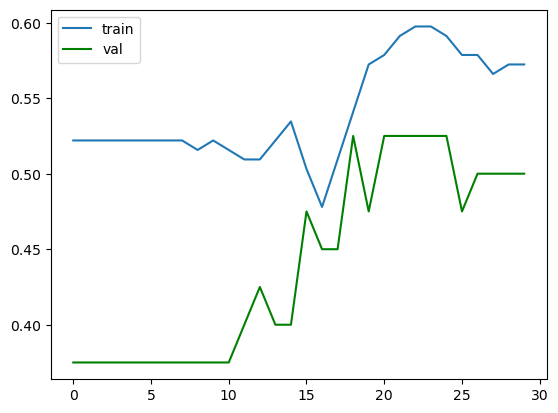

In [66]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], color='green', label='val')
plt.legend()